# Time-Series Forecasting of Carbon Monoxide and Nitrogen Dioxide Levels

Build predictive models to forecast daily or hourly concentrations of **CO(GT)** and **NO₂(GT)** based on historical data.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import numpy as np

warnings.filterwarnings('ignore')

In [2]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/airquality.csv'
df = pd.read_csv(url)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [3]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='str')

# Project Workflow

### **Deliverables**:
1. **Forecasting Models**:
   - Trained models for `CO(GT)` and `NO₂(GT)`.
2. **Forecast Visualization**:
   - Plots showing historical trends and future predictions.
3. **Evaluation Report**:
   - Metrics and comparison of different forecasting models.
4. **Insights and Recommendations**:
   - Suggestions for mitigating high levels of these gases based on predictions.


### 1. Data Preprocessing
- **Date-Time Parsing**:
  - Combine the `Date` and `Time` columns into a single `datetime` column.
  - Set the `datetime` column as the index of the dataset.
- **Resampling**:
  - Aggregate the data into meaningful time intervals (e.g., hourly or daily averages).
- **Handle Missing Values**:
  - Use interpolation, mean, or advanced imputation techniques to fill missing data for `CO(GT)` and `NO₂(GT)`.
- **Outlier Detection**:
  - Remove or cap extreme values in `CO(GT)` and `NO₂(GT)` using statistical thresholds.

In [4]:
# copy dataframe for date and time concatenation 
df_dt = df.copy()

In [5]:
df_dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1 MB


In [6]:
# Adding Date and time 
df_dt['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])
df_dt.set_index('datetime', inplace=True)
df_dt.index = pd.to_datetime(df_dt.index)
df_dt.index.name = 'datetime'

# Drop date and time columns
df_dt.drop(['Date', 'Time'], axis=1, inplace=True)
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [7]:
def aggregation(col_name):
    return df_dt[col_name].resample('d').mean()

print(aggregation('CO(GT)'))
print(aggregation('NO2(GT)'))

datetime
2004-03-10     1.966667
2004-03-11    -6.187500
2004-03-12   -14.095833
2004-03-13    -5.750000
2004-03-14    -5.966667
                ...    
2005-03-31     1.387500
2005-04-01    -7.270833
2005-04-02     0.854167
2005-04-03     1.141667
2005-04-04   -11.393333
Freq: D, Name: CO(GT), Length: 391, dtype: float64
datetime
2004-03-10    108.833333
2004-03-11     87.375000
2004-03-12     89.916667
2004-03-13    105.583333
2004-03-14     97.458333
                 ...    
2005-03-31    100.708333
2005-04-01    107.333333
2005-04-02    100.166667
2005-04-03    111.125000
2005-04-04    122.000000
Freq: D, Name: NO2(GT), Length: 391, dtype: float64


In [8]:
print(f'CO variable type : {df_dt['CO(GT)'].dtype}')
print(f'NO2 variable type : {df_dt['NO2(GT)'].dtype}')
print(f'T variable type : {df_dt['T'].dtype}')

CO variable type : float64
NO2 variable type : int64
T variable type : float64


In [9]:
def set_null():
    for i in df_dt.columns:
        df_dt[i] = df_dt[i].mask(df_dt[i] == -200, np.nan)

set_null()
df_dt.to_csv("airquality_replace_missing_value_66.csv")

In [10]:
# count total missing values
# count cosecutive missing values
def count_missing_val(col_name_cosec):
    is_na = df_dt[col_name_cosec].isna()
    max_strek = 0
    current_strek = 0

    for i in is_na:
        if i == True:
            current_strek += 1
            if current_strek > max_strek:
                max_strek = current_strek
        else:
            current_strek = 0

    return print(f'Total missing values (nan) of {col_name_cosec} : {df_dt[col_name_cosec].isna().sum()}\nMaximum Consecutive Missing for {col_name_cosec}: {max_strek}')

In [11]:
count_missing_val('CO(GT)')

Total missing values (nan) of CO(GT) : 1683
Maximum Consecutive Missing for CO(GT): 173


In [12]:
count_missing_val('NO2(GT)')

Total missing values (nan) of NO2(GT) : 1642
Maximum Consecutive Missing for NO2(GT): 173


In [13]:
# function for detecting gap of consecutive missing values
def measure_missing_val_gap(col_name_gap, consec_missing_val):
    is_na = df_dt[col_name_gap].isna()
    start = None
    count = 0
    for idx, val in is_na.items():
        if val:
            if start is None:
                start = idx
            count += 1
        else:
            if count == consec_missing_val:
                return print(f'{col_name_gap} - Gap Start : {start}\n{col_name_gap} - Gap End : {prev_idx}')
            start = None
            count = 0

        prev_idx = idx


measure_missing_val_gap('CO(GT)', 173)
print('-----------------------------------------')
measure_missing_val_gap('NO2(GT)', 173)


CO(GT) - Gap Start : 2004-10-13 11:00:00
CO(GT) - Gap End : 2004-10-20 15:00:00
-----------------------------------------
NO2(GT) - Gap Start : 2004-10-13 11:00:00
NO2(GT) - Gap End : 2004-10-20 15:00:00


In [14]:
# function for deleting consecutive missing values
def delete_consecutive_missing_val(col_name, df, threshold):

    is_missing = df[col_name].isna()

    current_streak = 0
    gap_start = None
    drop_index_list = []

    for t, miss in is_missing.items():
        if miss:
            if current_streak == 0:
                gap_start = t
            current_streak += 1
            gap_end = t
        else:
            if current_streak > threshold:
                drop_index_list.extend(df.loc[gap_start:gap_end].index)
            current_streak = 0
            gap_start = None

    if current_streak > threshold:
        drop_index_list.extend(df.loc[gap_start:gap_end].index)

    dropped = len(drop_index_list)
    df_new = df.drop(drop_index_list)

    print(f'{col_name} Consecutive Missing values - Dropped rows : {dropped}')
    return df_new

df_dt = delete_consecutive_missing_val('CO(GT)', df_dt, 24)
df_dt = delete_consecutive_missing_val('NO2(GT)', df_dt, 24)

CO(GT) Consecutive Missing values - Dropped rows : 1357
NO2(GT) Consecutive Missing values - Dropped rows : 148


In [15]:
# replace missing values of all features by Time Interpolation
def set_time_interpolate():
    for i in df_dt.columns:
        df_dt[i] = df_dt[i].interpolate(method='time')

set_time_interpolate()
df_dt.to_csv('airquality_test_1099.csv')

In [16]:
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [17]:
# Remove extreme values (Outlier)
def outlier_removal(col_name):
    outlier = []
    key_outlier = []
    global df_dt

    q1 = np.percentile(df_dt[col_name], 25)
    q3 = np.percentile(df_dt[col_name], 75)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    for key, i in enumerate (df_dt[col_name]):
        if i < lower_bound or i > upper_bound :
            outlier.append(i)
            key_outlier.append(key)

    print(f'Outliers : {outlier}')
    print(f'Outliers key : {key_outlier}')
    df_dt = df_dt.drop(df_dt.index[key_outlier])


In [82]:
for i in range(4):
    outlier_removal('CO(GT)')
    outlier_removal('NO2(GT)')

Outliers : []
Outliers key : []
Outliers : []
Outliers key : []
Outliers : []
Outliers key : []
Outliers : []
Outliers key : []
Outliers : []
Outliers key : []
Outliers : []
Outliers key : []
Outliers : []
Outliers key : []
Outliers : []
Outliers key : []


### 2. Exploratory Data Analysis (EDA)
- **Trend Analysis**:
  - Visualize the long-term trends of `CO(GT)` and `NO₂(GT)`.
- **Seasonality**:
  - Identify seasonal patterns (e.g., daily or yearly fluctuations).
- **Correlation Analysis**:
  - Explore relationships between `CO(GT)`, `NO₂(GT)`, and other features (e.g., temperature or humidity).


The NO₂(GT) time series shows a clear upward trend over time, indicating a gradual increase in pollution levels. In contrast, CO(GT) does not exhibit a strong long-term trend but shows significant short-term fluctuations, suggesting variability without consistent growth.

Trend Analysis

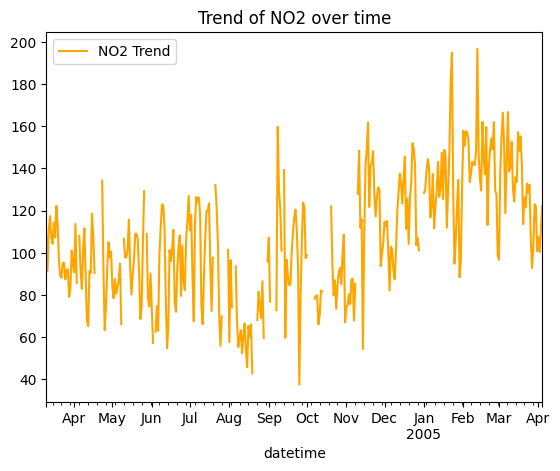

In [19]:
# Trend Analysis
# df_dt['CO(GT)'].rolling(window=24).mean().plot(label='CO Trend')
df_dt['NO2(GT)'].resample('D').mean().plot(label='NO2 Trend', color='orange')
plt.legend()
plt.title('Trend of NO2 over time')
plt.show()

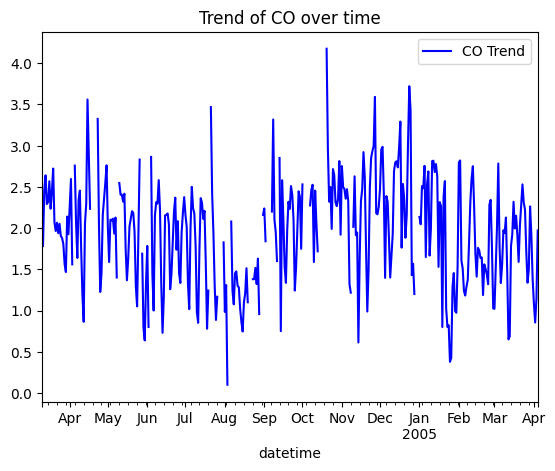

In [20]:
df_dt['CO(GT)'].resample('D').mean().plot(label='CO Trend', color='blue')
plt.legend()
plt.title('Trend of CO over time')
plt.show()

Seasonality Test

<Axes: xlabel='datetime'>

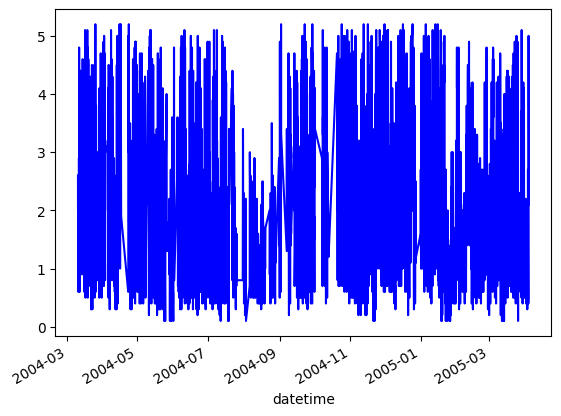

In [21]:
df_dt['CO(GT)'].plot(label='CO Seasonality Trend', color='blue')

<Axes: xlabel='datetime'>

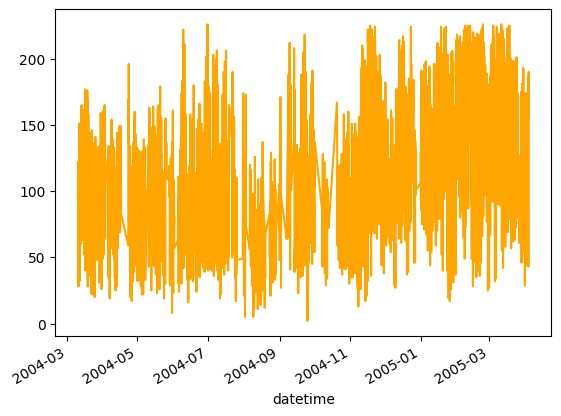

In [22]:
df_dt['NO2(GT)'].plot(label='NO2 Seasonality Trend', color='orange')

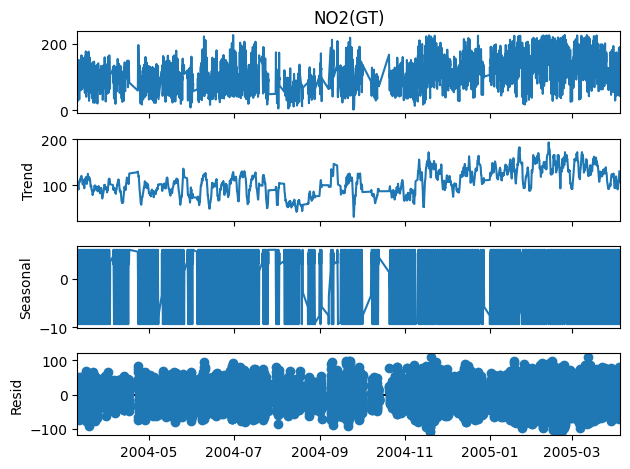

In [23]:
# seasonal decompossition graph for NO2
season_no2 = seasonal_decompose(df_dt['NO2(GT)'], model='additive', period=24)
season_no2.plot()
plt.show()

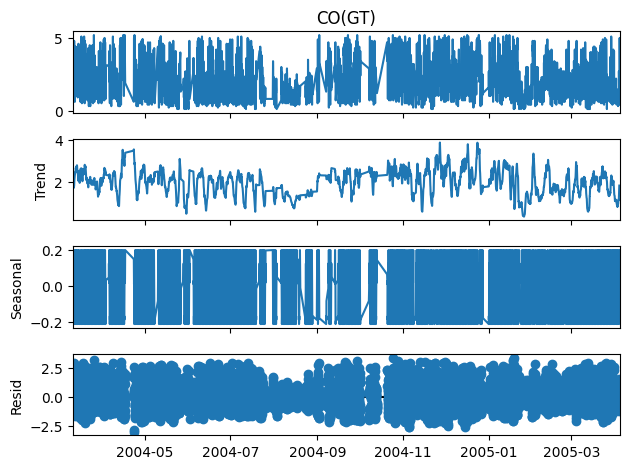

In [24]:
# seasonal decompossition graph for CO
season_no2 = seasonal_decompose(df_dt['CO(GT)'], model='additive', period=24)
season_no2.plot()
plt.show()

Correlation Analysis

In [25]:
# correlation analysis with respect to CO 
def corr_analysis(col_name):
    corr_of_co = df_dt.corr()[col_name].sort_values(ascending=False)
    return pd.DataFrame(corr_of_co)

corr_analysis('CO(GT)')

,CO(GT)
CO(GT),1.000000
PT08.S2(NMHC),0.884637
C6H6(GT),0.882226
PT08.S1(CO),0.836814
PT08.S5(O3),0.812020
NOx(GT),0.741803
NO2(GT),0.686620
PT08.S4(NO2),0.581368
NMHC(GT),0.264553
T,0.086478


In [26]:
# correlation analysis with respect to NO2
corr_analysis('NO2(GT)')

,NO2(GT)
NO2(GT),1.000000
NOx(GT),0.740109
CO(GT),0.686620
PT08.S5(O3),0.671809
PT08.S2(NMHC),0.617432
PT08.S1(CO),0.616779
C6H6(GT),0.583448
NMHC(GT),0.182468
PT08.S4(NO2),0.103580
RH,-0.141671



### 3. Feature Engineering
- Create lag features for `CO(GT)` and `NO₂(GT)` to incorporate historical values.
- Add time-based features (e.g., hour of the day, day of the week, month).
- Include environmental factors (`T`, `RH`, `AH`) as predictors.


Autocorrelation Plots (ACF)

In [27]:
# ACF Plot 
def acf_plot(col_name):
    plot_acf(df_dt[col_name].dropna(), lags=40)
    return plt.show()


CO(GT) ACF Plot : 


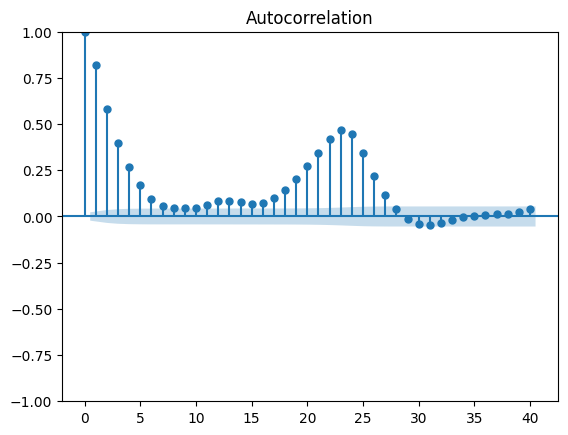

NO2(GT) ACF Plot : 


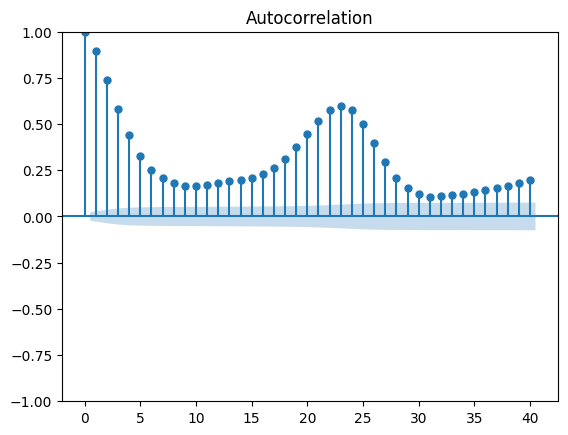

In [28]:
# acf plots for CO and NO2
print('CO(GT) ACF Plot : ')
acf_plot('CO(GT)')

print('NO2(GT) ACF Plot : ')
acf_plot('NO2(GT)')

Partial Autocorrelation Plot (PACF)

In [29]:
def pacf_plot(col_name):
    plot_pacf(df_dt[col_name].dropna(), lags=40)
    return plt.show()

CO(GT) PACF Plot : 


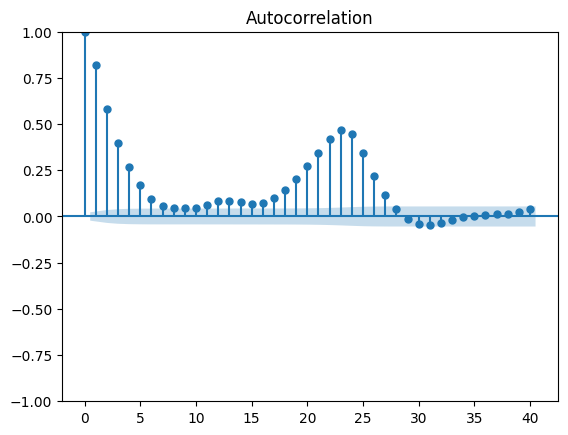

NO2(GT) PACF Plot : 


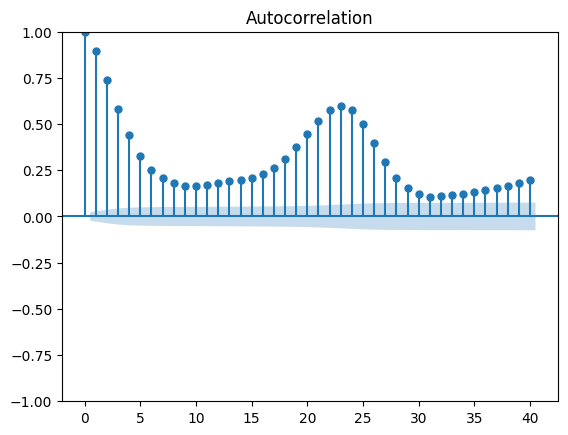

In [30]:
# pacf plots for CO and NO2

print('CO(GT) PACF Plot : ')
acf_plot('CO(GT)')

print('NO2(GT) PACF Plot : ')
acf_plot('NO2(GT)')

In [31]:
# function of lag features
def lag_feature(lag_name, col_name, lag_shift):
    df_dt[lag_name] = df_dt[col_name].shift(lag_shift)


In [32]:
# add lag features in CO 
lag_feature('CO_lag_1', 'CO(GT)', 1)
lag_feature('CO_lag_2', 'CO(GT)', 2)
lag_feature('CO_lag_3', 'CO(GT)', 3)
lag_feature('CO_lag_24', 'CO(GT)', 24)

# add lag features in NO2
lag_feature('NO2_lag_1', 'NO2(GT)', 1)
lag_feature('NO2_lag_2', 'NO2(GT)', 2)
lag_feature('NO2_lag_3', 'NO2(GT)', 3)
lag_feature('NO2_lag_24', 'NO2(GT)', 24)

df_dt = df_dt.dropna()
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),...,RH,AH,CO_lag_1,CO_lag_2,CO_lag_3,CO_lag_24,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_24
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-11 18:00:00,4.8,1581.0,307.0,20.8,1319.0,281.0,799.0,151.0,2083.0,1409.0,...,64.2,0.8065,2.9,2.2,2.2,2.6,135.0,131.0,126.0,113.0
2004-03-11 21:00:00,3.9,1313.0,197.0,12.8,1076.0,240.0,957.0,136.0,1707.0,1285.0,...,64.0,0.7419,4.8,2.9,2.2,2.0,151.0,135.0,131.0,92.0
2004-03-11 22:00:00,1.5,965.0,61.0,4.7,749.0,94.0,1325.0,85.0,1333.0,821.0,...,63.4,0.6905,3.9,4.8,2.9,2.2,136.0,151.0,135.0,114.0
2004-03-11 23:00:00,1.0,913.0,26.0,2.6,629.0,47.0,1565.0,53.0,1252.0,552.0,...,60.8,0.6657,1.5,3.9,4.8,2.2,85.0,136.0,151.0,122.0
2004-03-12 00:00:00,1.7,1080.0,55.0,5.9,805.0,122.0,1254.0,97.0,1375.0,816.0,...,58.5,0.6438,1.0,1.5,3.9,1.6,53.0,85.0,136.0,116.0


In [33]:
# time based features
df_dt['hour'] = df_dt.index.hour
df_dt['day_of_week'] = df_dt.index.dayofweek
df_dt['month'] = df_dt.index.month

df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),...,CO_lag_2,CO_lag_3,CO_lag_24,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_24,hour,day_of_week,month
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-11 18:00:00,4.8,1581.0,307.0,20.8,1319.0,281.0,799.0,151.0,2083.0,1409.0,...,2.2,2.2,2.6,135.0,131.0,126.0,113.0,18,3,3
2004-03-11 21:00:00,3.9,1313.0,197.0,12.8,1076.0,240.0,957.0,136.0,1707.0,1285.0,...,2.9,2.2,2.0,151.0,135.0,131.0,92.0,21,3,3
2004-03-11 22:00:00,1.5,965.0,61.0,4.7,749.0,94.0,1325.0,85.0,1333.0,821.0,...,4.8,2.9,2.2,136.0,151.0,135.0,114.0,22,3,3
2004-03-11 23:00:00,1.0,913.0,26.0,2.6,629.0,47.0,1565.0,53.0,1252.0,552.0,...,3.9,4.8,2.2,85.0,136.0,151.0,122.0,23,3,3
2004-03-12 00:00:00,1.7,1080.0,55.0,5.9,805.0,122.0,1254.0,97.0,1375.0,816.0,...,1.5,3.9,1.6,53.0,85.0,136.0,116.0,0,4,3


In [34]:
df_dt.to_csv('dataset_clean.csv')

In [35]:
# feature selection for X and Y split for CO(GT)
X_of_co = df_dt[['T', 'RH', 'AH', 'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'CO_lag_24', 'hour', 'day_of_week', 'month']]
y_of_co = df_dt['CO(GT)']

# feature selection for X and Y split NO2(GT)
X_of_no2 = df_dt[['T', 'RH', 'AH', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_24', 'hour', 'day_of_week', 'month']]
y_of_no2 = df_dt['NO2(GT)']


In [36]:
X_of_co.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7421 entries, 2004-03-11 18:00:00 to 2005-04-04 14:00:00
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T            7421 non-null   float64
 1   RH           7421 non-null   float64
 2   AH           7421 non-null   float64
 3   CO_lag_1     7421 non-null   float64
 4   CO_lag_2     7421 non-null   float64
 5   CO_lag_3     7421 non-null   float64
 6   CO_lag_24    7421 non-null   float64
 7   hour         7421 non-null   int32  
 8   day_of_week  7421 non-null   int32  
 9   month        7421 non-null   int32  
dtypes: float64(7), int32(3)
memory usage: 550.8 KB


In [37]:
X_of_no2.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7421 entries, 2004-03-11 18:00:00 to 2005-04-04 14:00:00
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T            7421 non-null   float64
 1   RH           7421 non-null   float64
 2   AH           7421 non-null   float64
 3   NO2_lag_1    7421 non-null   float64
 4   NO2_lag_2    7421 non-null   float64
 5   NO2_lag_3    7421 non-null   float64
 6   NO2_lag_24   7421 non-null   float64
 7   hour         7421 non-null   int32  
 8   day_of_week  7421 non-null   int32  
 9   month        7421 non-null   int32  
dtypes: float64(7), int32(3)
memory usage: 550.8 KB


In [38]:
# train and test split 
X_train_co, X_test_co, y_train_co, y_test_co = train_test_split(X_of_co, 
                                                                y_of_co, 
                                                                test_size=0.30, 
                                                                random_state=2, 
                                                                shuffle=False)

X_train_no2, X_test_no2, y_train_no2, y_test_no2 = train_test_split(X_of_no2, 
                                                                    y_of_no2, 
                                                                    test_size=0.30, 
                                                                    random_state=2, 
                                                                    shuffle=False)

### 4. Time-Series Forecasting
- Train separate models for **CO(GT)** and **NO₂(GT)**.
- Explore the following forecasting approaches:
  - **Statistical Models**:
    - Classical models like ARIMA or SARIMA for univariate forecasting.
  - **Machine Learning Models**:
    - Use regression models trained on lag features and external predictors.
  - **Deep Learning Models**:
    - Apply LSTM, GRU, or other RNN-based models for sequence forecasting.
- Evaluate and compare the models.


Seasonal Auto Regressive Moving Average (SARIMA)

In [39]:
# Augmented Dickey-Fuller Test (p Value measurment)
def adf_test(col_name):
    result = adfuller(df_dt[col_name].dropna())
    if result[1] <= 0.05:
        print(f'{col_name} is Stationary with p Value = {result}')
    else:
        print(f'{col_name} is Non-Stationary with p Value = {result}')

adf_test('CO(GT)')
adf_test('NO2(GT)')


CO(GT) is Stationary with p Value = (np.float64(-10.070311545437319), np.float64(1.2640721693416274e-17), 34, 7386, {'1%': np.float64(-3.431235672100475), '5%': np.float64(-2.861931399130876), '10%': np.float64(-2.5669783374375994)}, np.float64(13601.587001663682))
NO2(GT) is Stationary with p Value = (np.float64(-7.083941377123859), np.float64(4.589964955290744e-10), 26, 7394, {'1%': np.float64(-3.43123471350717), '5%': np.float64(-2.861930975569223), '10%': np.float64(-2.566978111969519)}, np.float64(63258.78331069542))


In [40]:
# seasonal p from ACF 
def seasonal_acf(col_name):
    acf_val = acf(df_dt[col_name], nlags=24)
    return acf_val[24]

# seasonal q from PACF
def seasonal_pacf(col_name):
    pacf_val = pacf(df_dt[col_name], nlags=24)
    return pacf_val[24]

print(f'seasonal P of CO(GT) in 24 Lag (acf): {seasonal_acf('CO(GT)')}')
print(f'seasonal P of NO2(GT) in 24 Lag (acf): {seasonal_acf('NO2(GT)')}')

print(f'seasonal q of CO(GT) in 24 Lag (pacf): {seasonal_pacf('CO(GT)')}')
print(f'seasonal q of NO2(GT) in 24 Lag (pacf): {seasonal_pacf('NO2(GT)')}')


seasonal P of CO(GT) in 24 Lag (acf): 0.445164258138221
seasonal P of NO2(GT) in 24 Lag (acf): 0.5744660823487325
seasonal q of CO(GT) in 24 Lag (pacf): -0.04846892110493313
seasonal q of NO2(GT) in 24 Lag (pacf): -0.06659075882607976


In [41]:
# seasonal d (diffrencing)
def seasonal_diff(col_name):
    seasonal_diff_val = df_dt[col_name].diff(24).dropna()
    result = adfuller(seasonal_diff_val)
    return result[1]

print(f'seasonal p-Value of CO(GT): {seasonal_diff('CO(GT)')}')
print(f'seasonal p-Value of NO2(GT): {seasonal_diff('NO2(GT)')}')


seasonal p-Value of CO(GT): 3.979860588404527e-30
seasonal p-Value of NO2(GT): 4.355732821082157e-30


In [42]:
# Manual paramerter selection for SARIMA
# defination of p, d, q for CO(GT) - order
p_order_co = 1 # based on pacf plot of CO(GT)
d_order_co = 0 # stationaty and p_value is <= 0.05
q_order_co = 1 # based on acf plot of CO(GT)

# defination of p, d, q for NO2(GT) - order
p_order_co = 1 # based on pacf plot of NO2(GT)
d_order_co = 0 # stationaty and p_value is <= 0.05
q_order_co = 1 # based on acf plot of NO2(GT)

# defination of p, d, q for CO(GT) - seasonal
s_season = 24 
d_season_co = 0 
q_season_co = 0 
p_season_co = 1

# defination of p, d, q for NO2(GT) - seasonal
s_season = 24 
d_season_no2 = 0 
q_season_no2 = 1 
p_season_no2 = 1

In [43]:
# function of evaluting the sarima parameters through auto arima model 
# def auto_arima_params(col_name):
#     model = pm.auto_arima(df_dt[col_name].iloc[-700:], seasonal=True, m=24)
#     return model.summary() , model.plot_diagnostics(figsize=(12, 8))

# summary of CO(GT)
# auto_arima_params('CO(GT)')

In [44]:
# arima summary of NO2(GT)
# auto_arima_params('NO2(GT)')

In [45]:
# SARIMA Model training 
class ModelSARIMA:
    def model_sarima(self, X, y, p, d, q, P, D, Q, S):
         return SARIMAX(y, 
                        exog=X, 
                        order=(p, d, q), 
                        seasonal_order=(P, D, Q, S),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

In [46]:
obj_co_sarima_model = ModelSARIMA()
co_result = obj_co_sarima_model.model_sarima(X_train_co, 
                                        y_train_co, 
                                        0, 0, 0, 
                                        1, 0, 0, 24).fit(disp=False)

print(co_result.summary())

                                SARIMAX Results                                 
Dep. Variable:                   CO(GT)   No. Observations:                 5194
Model:             SARIMAX(1, 0, 0, 24)   Log Likelihood               -4908.488
Date:                  Thu, 02 Apr 2026   AIC                           9840.975
Time:                          22:44:52   BIC                           9919.583
Sample:                               0   HQIC                          9868.479
                                 - 5194                                         
Covariance Type:                    opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
T               0.0146      0.002      6.062      0.000       0.010       0.019
RH              0.0075      0.001      8.362      0.000       0.006       0.009
AH             -0.2371      0.05

In [47]:
obj_no2_sarima_model = ModelSARIMA()
no2_result = obj_no2_sarima_model.model_sarima(X_train_no2, 
                                               y_train_no2, 0, 1, 1, 
                                               1, 0, 0, 24).fit(disp=False)
print(no2_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             NO2(GT)   No. Observations:                 5194
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 24)   Log Likelihood              -22002.081
Date:                             Thu, 02 Apr 2026   AIC                          44030.162
Time:                                     22:45:53   BIC                          44115.317
Sample:                                          0   HQIC                         44059.957
                                            - 5194                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
T              -0.5016      0.155     -3.233      0.001      -0.806      -0.198
RH             -0.6939  

SARIMA Forecasting

In [48]:
class TimeSeriesForecaster:
    def __init__(self):
        self.results = {} 
        
    def run_forecast(self, yTest, xTest, model_result, name):
        tag_forecast = model_result.get_forecast(steps=len(yTest), exog=xTest)
        
        self.results[name] = {
            'y_forecast': tag_forecast.predicted_mean,
            'conf_interval': tag_forecast.conf_int(),
            'forecast_df': pd.DataFrame({
                'Actual': yTest.values, 
                'Forecast': tag_forecast.predicted_mean.values
            }, index=yTest.index)
        }

        return self.results[name]['forecast_df']

In [49]:
forecasting = TimeSeriesForecaster()
df_forecast_no2 = forecasting.run_forecast(y_test_no2, X_test_no2, no2_result, 'NO2')
df_forecast_no2.head(20)

,Actual,Forecast
datetime,,
2004-12-19 23:00:00,126.0,125.877507
2004-12-20 00:00:00,127.0,123.363384
2004-12-20 01:00:00,118.0,136.620927
2004-12-20 02:00:00,83.0,132.464206
2004-12-20 03:00:00,71.5,99.844055
2004-12-20 04:00:00,60.0,99.468081
2004-12-20 05:00:00,37.0,96.000993
2004-12-20 06:00:00,39.0,82.328399
2004-12-20 07:00:00,70.0,88.898881


In [50]:
df_forecast_co = forecasting.run_forecast(y_test_co, X_test_co, co_result, 'CO')
df_forecast_co.head(20)

,Actual,Forecast
datetime,,
2004-12-19 23:00:00,2.9,2.439259
2004-12-20 00:00:00,3.1,2.810223
2004-12-20 01:00:00,2.8,3.226365
2004-12-20 02:00:00,1.2,2.677491
2004-12-20 03:00:00,0.9,0.709866
2004-12-20 04:00:00,0.8,1.239426
2004-12-20 05:00:00,0.6,1.171262
2004-12-20 06:00:00,0.6,0.958564
2004-12-20 07:00:00,1.0,0.979650


In [51]:
def forecast_plot(yTest, df_forecast, conf_int, col_name):
    plt.figure(figsize=(12, 6))
    
    y_true = yTest.iloc[:120]
    y_pred = df_forecast.iloc[:120]
    ci = conf_int.iloc[:120]

    plt.plot(y_true.index, y_true.values, label='Actual', color='blue', alpha=0.6)
    plt.plot(y_true.index, y_pred.values, label='Forecast', color='red', linestyle='--')

    plt.fill_between(y_true.index, 
                     ci.iloc[:, 0], 
                     ci.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

    plt.title(f'{col_name} SARIMA Forecasting Results')
    plt.xlabel('Date/Time')
    plt.ylabel('Concentration')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [52]:
co_confidence_interval = forecasting.results['CO']['conf_interval']
no2_confidence_interval = forecasting.results['NO2']['conf_interval']

In [53]:
co_confidence_interval.head()

,lower CO(GT),upper CO(GT)
5194,1.213587,3.664932
5195,1.584550,4.035895
5196,2.000693,4.452038
5197,1.451819,3.903164
5198,-0.515806,1.935539


In [54]:
no2_confidence_interval.head()

,lower NO2(GT),upper NO2(GT)
5194,92.382357,159.372657
5195,89.348924,157.377844
5196,102.094967,171.146887
5197,97.434214,167.494198
5198,64.317182,135.370928


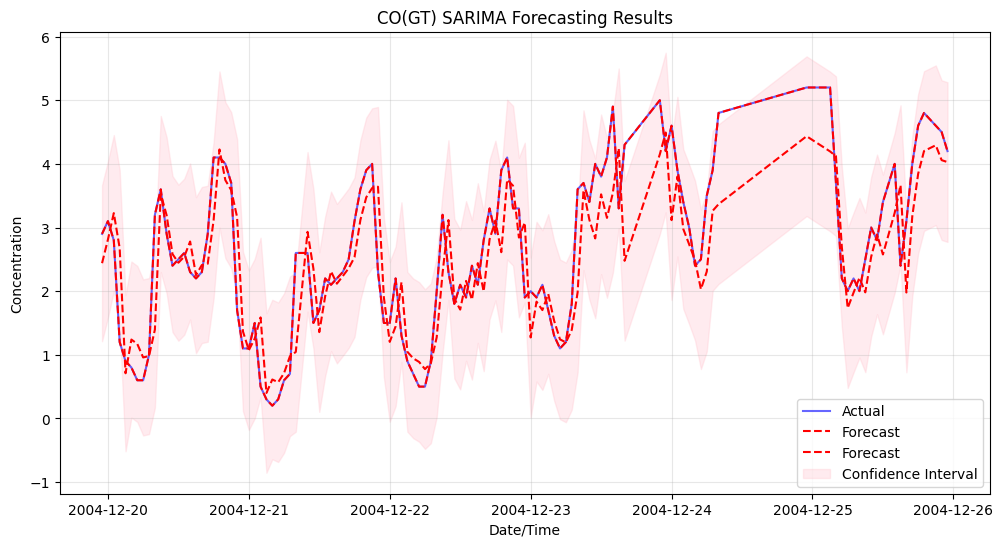

In [55]:
# forecast plot for CO
forecast_plot(y_test_co, 
              df_forecast_co,
              co_confidence_interval,
              'CO(GT)')

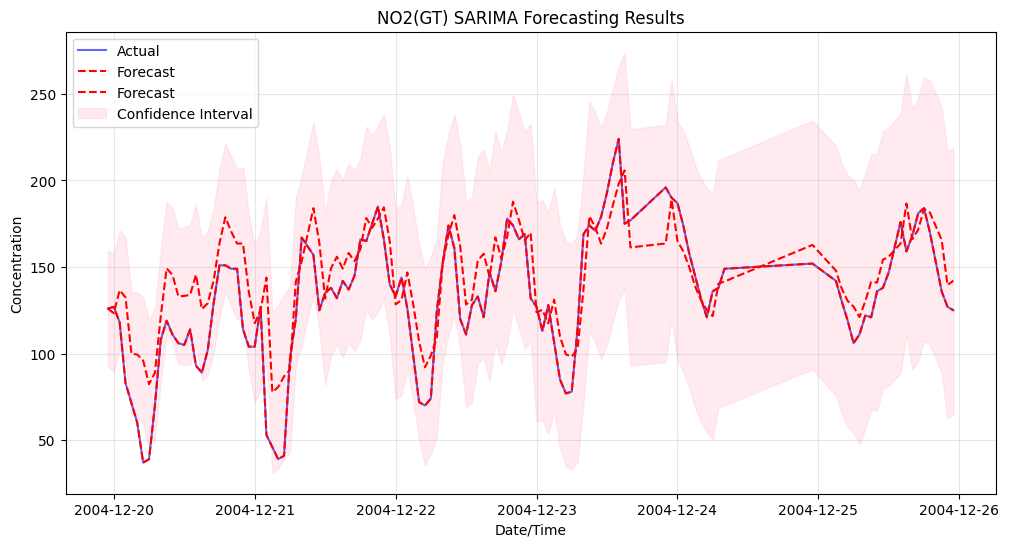

In [56]:
# forecast plot fot NO2
forecast_plot(y_test_no2, 
              df_forecast_no2,
              no2_confidence_interval,
              'NO2(GT)')

### 5. Model Evaluation
- Use appropriate metrics for forecasting:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - Mean Absolute Percentage Error (MAPE)
- Plot actual vs. predicted values to visualize performance.


In [134]:
# Evaluation
class Eval:
    def eval(self, df_name, col_name):
        mean_ = df_name['Actual'].mean()
        r_square = r2_score(df_name['Actual'], df_name['Forecast'])
        rmse_ = np.sqrt(mean_squared_error(df_name['Actual'], df_name['Forecast']))
        mae_ = mean_absolute_error(df_name['Actual'], df_name['Forecast'])
        mape_ = (rmse_ / mean_) * 100

        eval_results = {
            "feature_name" : col_name,
            "feature_mean" : mean_,
            "feature_rmse" : rmse_,
            "feature_mae" : mae_,
            "feature_mape" : mape_,
            "feature_r_square" : r_square
        }

        return eval_results

In [ ]:
obj_eval = Eval()
# result = obj_eval.eval(df_forecast_co, 'CO')
# result['feature_name']
result_sarima_co = obj_eval.eval(df_forecast_co, 'CO')
result_sarima_no2 = obj_eval.eval(df_forecast_no2, 'NO2')

data = {
    'Mean': [result_sarima_co['feature_mean'], result_sarima_no2['feature_mean']],
    'R Square': [result_sarima_co['feature_r_square'], result_sarima_no2['feature_r_square']],
    'RMSE': [result_sarima_co['feature_rmse'], result_sarima_no2['feature_rmse']],
    'MAE': [result_sarima_co['feature_mae'], result_sarima_no2['feature_mae']],
    'MAPE (%)': [result_sarima_co['feature_mape'], result_sarima_no2['feature_mape']]
}

performance_df = pd.DataFrame(data, index=[result_sarima_co['feature_name'], 
                                           result_sarima_no2['feature_name']
                                           ])

print('SARIMA Model performance evaluation for CO(GT) and NO2(GT)')
performance_df

SARIMA Model performance evaluation for CO(GT) and NO2(GT)


,Mean,RMSE,MAE,MAPE (%)
CO,1.826089,0.598113,0.425752,32.753767
NO2,132.191513,25.721491,20.330798,19.457748


### 6. Visualization and Insights
- Generate forecasts for future dates and visualize the trends.
- Highlight seasonal patterns, peak times, and periods of concern.
- Provide actionable recommendations based on predicted trends.

